In [37]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Load data
df = pd.read_excel("../Pupilometri/Left_manually_cleaned_artefacts.xlsx", sheet_name=0,skiprows=8)
df = df.dropna(axis=1)
df = df.drop('Time', axis=1) # normally 30hz 
df_skip = df.iloc[::10] # 3 hz

# Apply PCA
pca = PCA(n_components=10)
principal_components = pca.fit_transform(df_skip.T)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Principal components shape:", principal_components.shape)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

Explained variance ratio: [9.59351232e-01 2.81959871e-02 6.93033069e-03 2.09580490e-03
 1.10053735e-03 8.62535705e-04 3.42266536e-04 2.62855329e-04
 1.68120316e-04 1.12893670e-04]
Principal components shape: (247, 10)


In [39]:
loadings = pd.DataFrame(
    pca.components_.T,        # shape (10,39)
    index=df_skip.index,       
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

Text(0.5, 1.0, 'PC1 distribution across patients')

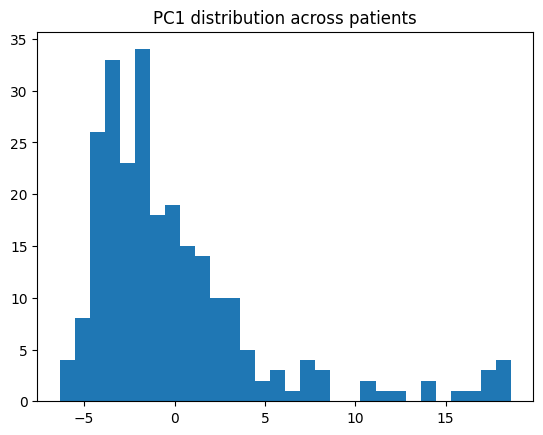

In [40]:
pc1_scores = principal_components[:,0]

plt.hist(pc1_scores, bins=30)
plt.title("PC1 distribution across patients")

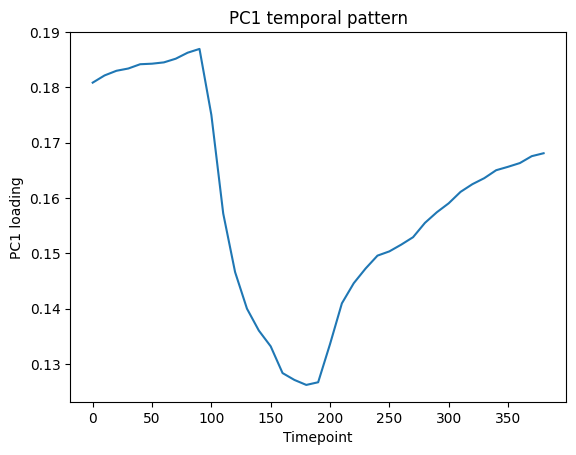

In [ ]:
import matplotlib.pyplot as plt
#PLot loadings OF PC1 over time
plt.plot(df_skip.index, loadings["PC1"])
plt.xlabel("Timepoint")
plt.ylabel("PC1 loading")
plt.title("PC1 temporal pattern")
plt.show()

In [42]:
mean_signal = df_skip.mean(axis=1)

import numpy as np
np.corrcoef(mean_signal, loadings["PC1"])[0,1]

np.float64(0.8718217416159935)

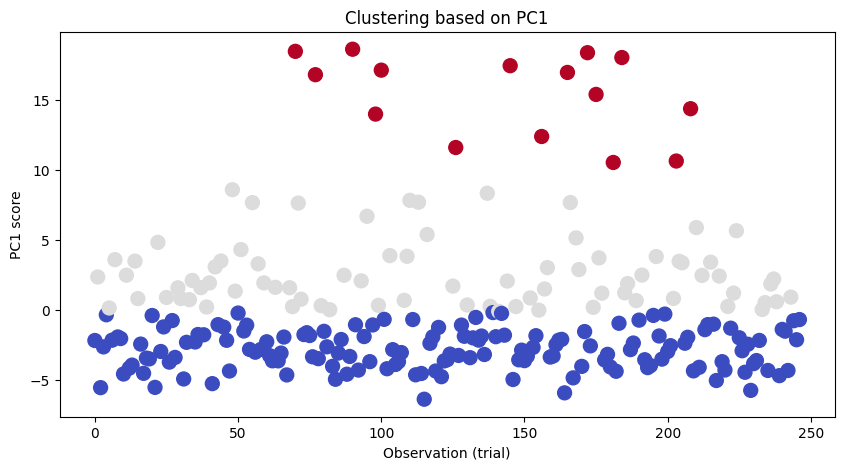

In [43]:
# Cluster only on PC1
from sklearn.cluster import KMeans
X = principal_components 
kmeans_pc1 = KMeans(n_clusters=3, random_state=42)
clusters_pc1 = kmeans_pc1.fit_predict(X[:,0].reshape(-1,1))

plt.figure(figsize=(10,5))
plt.scatter(range(len(clusters_pc1)), X[:,0], c=clusters_pc1, cmap='coolwarm', s=100)
plt.xlabel("Observation (trial)")
plt.ylabel("PC1 score")
plt.title("Clustering based on PC1")
plt.show()

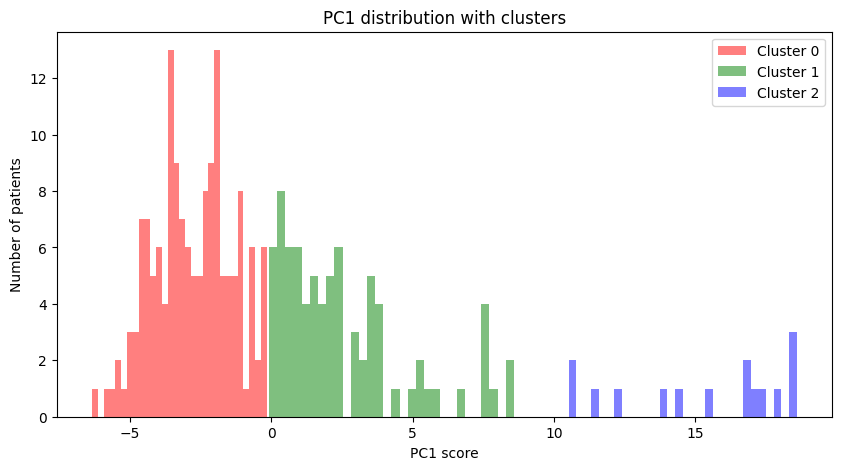

In [44]:
import numpy as np

clusters_pc1 = kmeans_pc1.fit_predict(pc1_scores.reshape(-1, 1))
colors = ['red', 'green', 'blue']

plt.figure(figsize=(10,5))
for cluster_id in np.unique(clusters_pc1):
    cluster_scores = pc1_scores[clusters_pc1 == cluster_id]
    plt.hist(cluster_scores, bins=30, alpha=0.5, label=f'Cluster {cluster_id}', color=colors[cluster_id])

plt.xlabel("PC1 score")
plt.ylabel("Number of patients")
plt.title("PC1 distribution with clusters")
plt.legend()
plt.show()

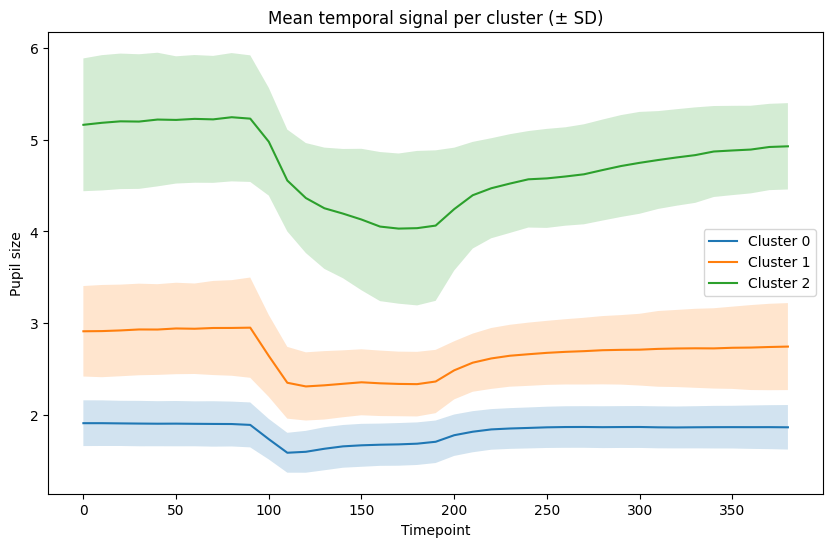

In [45]:
plt.figure(figsize=(10,6))

for cluster_id in np.unique(clusters_pc1):
    cluster_trials = df_skip.columns[clusters_pc1 == cluster_id]
    
    mean_signal = df_skip[cluster_trials].mean(axis=1)
    sd_signal = df_skip[cluster_trials].std(axis=1)
    
    # Plot mean line
    plt.plot(df_skip.index, mean_signal, label=f'Cluster {cluster_id}')
    
    # Add shaded SD area
    plt.fill_between(
        df_skip.index,
        mean_signal - sd_signal,
        mean_signal + sd_signal,
        alpha=0.2
    )

plt.xlabel("Timepoint")
plt.ylabel("Pupil size")
plt.title("Mean temporal signal per cluster (± SD)")
plt.legend()
plt.show()

In [46]:
from collections import Counter

cluster_counts = Counter(clusters_pc1)
print(cluster_counts)

Counter({np.int32(0): 154, np.int32(1): 78, np.int32(2): 15})


# Standardize pupil size (EXPLORTIVE)

In [47]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_skip)
# Apply PCA
pca = PCA(n_components=10)
principal_components = pca.fit_transform(X_scaled.T)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Principal components shape:", principal_components.shape)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

Explained variance ratio: [0.38741147 0.18229741 0.13371775 0.06323167 0.03734286 0.03364756
 0.02320085 0.01963977 0.01492526 0.01141573]
Principal components shape: (247, 10)


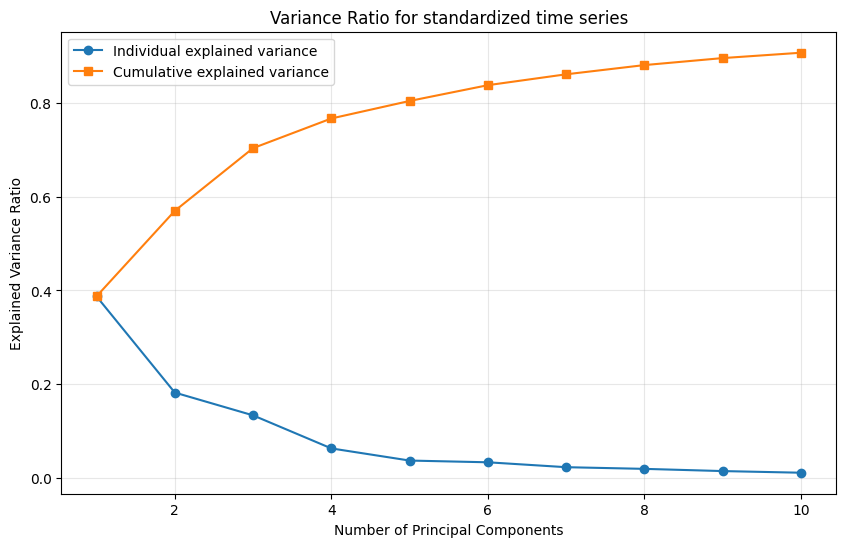

In [48]:
plt.figure(figsize=(10,6))

# Individual explained variance
plt.plot(range(1, len(explained_variance)+1),
         explained_variance,
         marker='o',
         label='Individual explained variance')

# Cumulative explained variance
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='s',
         label='Cumulative explained variance')

plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance Ratio for standardized time series')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


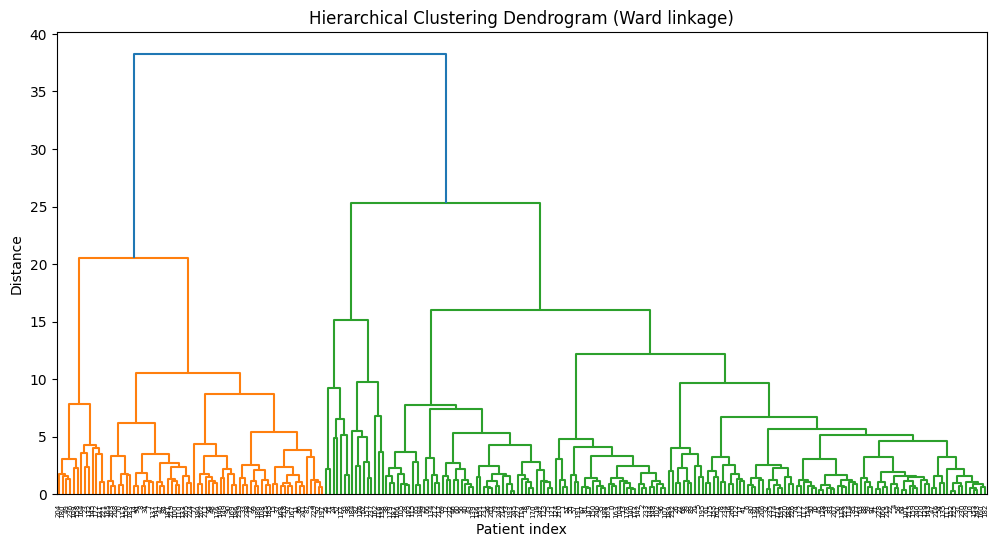

In [50]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Use first 6 PCs
X = principal_components[:, :6]  # shape: patients × 6 PCs

# Compute linkage matrix
Z = linkage(X, method='ward')  # 'ward' minimizes variance within clusters

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=np.arange(X.shape[0]), leaf_rotation=90, leaf_font_size=5)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.xlabel("Patient index")
plt.ylabel("Distance")
plt.show()

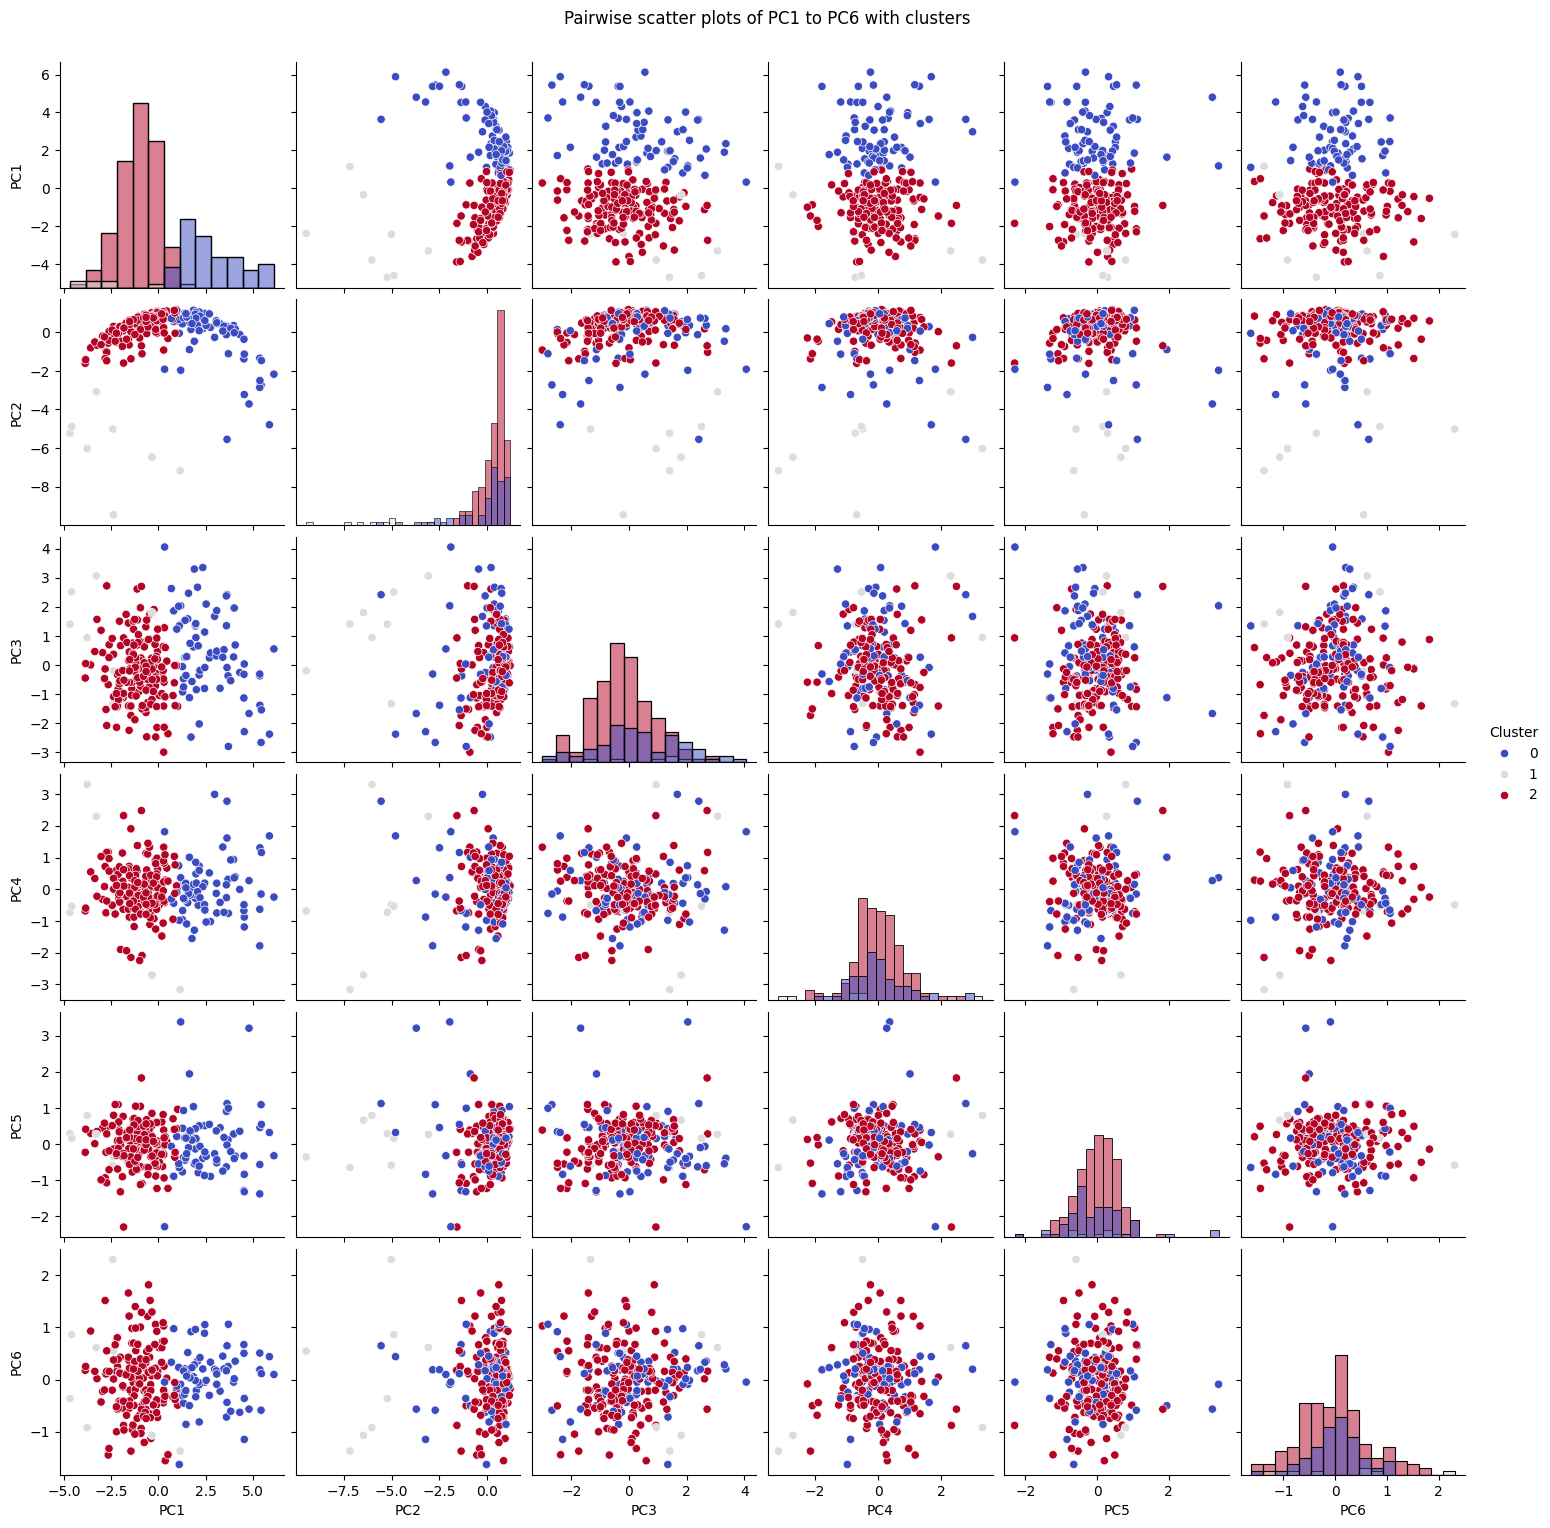

In [51]:
from sklearn.cluster import KMeans

# KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Use first 6 PCs
X_df = pd.DataFrame(X, columns=[f"PC{i+1}" for i in range(6)])
X_df['Cluster'] = clusters  # add cluster labels

# Pairplot (scatterplots for each pair of PCs)
sns.pairplot(X_df, hue='Cluster', palette='coolwarm', corner=False, diag_kind='hist', markers='o')
plt.suptitle("Pairwise scatter plots of PC1 to PC6 with clusters", y=1.02)
plt.show()

In [52]:
import numpy as np
unique_clusters, counts = np.unique(clusters, return_counts=True)
for cluster, count in zip(unique_clusters, counts):
    print(f"Cluster {cluster}: {count} patients")

Cluster 0: 71 patients
Cluster 1: 8 patients
Cluster 2: 168 patients


In [ ]:
df = pd.read_excel("../Pupilometri/Right_manually_cleaned_artefacts.xlsx", sheet_name=0,skiprows=8)
df = df.dropna(axis=1)
df = df.drop('Time', axis=1)
df_skip = df.iloc[::10]

# Apply PCA
pca = PCA(n_components=10)
principal_components = pca.fit_transform(df_skip.T)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Principal components shape:", principal_components.shape)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

Explained variance ratio: [9.52104689e-01 3.21653013e-02 9.81563871e-03 2.30384743e-03
 1.11727686e-03 6.76299057e-04 3.94230635e-04 3.33801678e-04
 2.07393542e-04 1.97452475e-04]
Principal components shape: (250, 10)
